<h3> Informações Iniciais para Realização da Atividade 2</h3>
 
<ul>
<li><b>Predict Students' Dropout and Academic Success</li>
<li><b>URL:</b> 
<a href="https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success" target="_blank">
https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success
</a>
</li>
<li><b>Número de Colunas (Atributos):</b> 36</li>
<li><b>Número de Objetos (Instâncias):</b> 4424</li>
<li><b>Número de Rótulos:</b> 1</li>
<li><b>Possui dados faltantes:</b> Não</li>
<li><b>Possui dados categóricos:</b> Sim</li>
</ul>

<p style="text-align: justify;">
  O código completo apresentado abaixo corresponde à etapa inicial do processo de Mineração de Dados, tendo como foco a leitura e visualização de um dataset, bem como a normalização dos dados e verificação da correlação entre os campos presentes no Dataset escolhido, visto que a limpeza não é necessária devido à falta de dados nulos ou duvidosos. Essas etapas são fundamentais para garantir maior qualidade e confiabilidade nas análises realizadas nas fases seguintes do processo de mineração de dados.
</p>

<p style="text-align: justify;">
  Essa etapa torna-se necessária devido à grande quantidade de informações coletadas atualmente em diversos setores da sociedade, especialmente por grandes empresas de tecnologia (Big Techs). Entretanto, nem todos os dados coletados são necessariamente úteis ou relevantes para a análise proposta. Assim, o processo de tratamento de dados tem como objetivo filtrar definir a relação entre as variáveis utilizando a matriz de correlação e filtrar variáveis relevantes por meio do método de Análise de Componentes Principais (PCA), visto em sala de aula.
</p>

In [1]:

# Importação da biblioteca pandas para manipulação de DataFrames, seaborn para criação do heatmap da matriz de correlação, 
# Importação do matplotlib para exibição em gráfico e do sklearn para normalização dos dados e implementação do método PCA.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler


In [2]:

# Leitura do arquivo .csv por meio da biblioteca pandas e atribuição à variável processed_students_df para manipulação dos dados
original_students_df = pd.read_csv("predict_students_dropout_and_academic_success.csv", sep = ";")
processed_students_df = original_students_df.copy()


In [3]:

# Verificação do desbalanceamento do rótulo Target para futuras análises de resultados
print(original_students_df["Target"].value_counts())


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [4]:

# Separação da coluna com rótulo "Target" do resto do dataset para uso futuro
y = original_students_df["Target"];
processed_students_df.drop("Target", axis = 1, errors = "ignore", inplace = True)
processed_students_df.columns = processed_students_df.columns.str.strip()


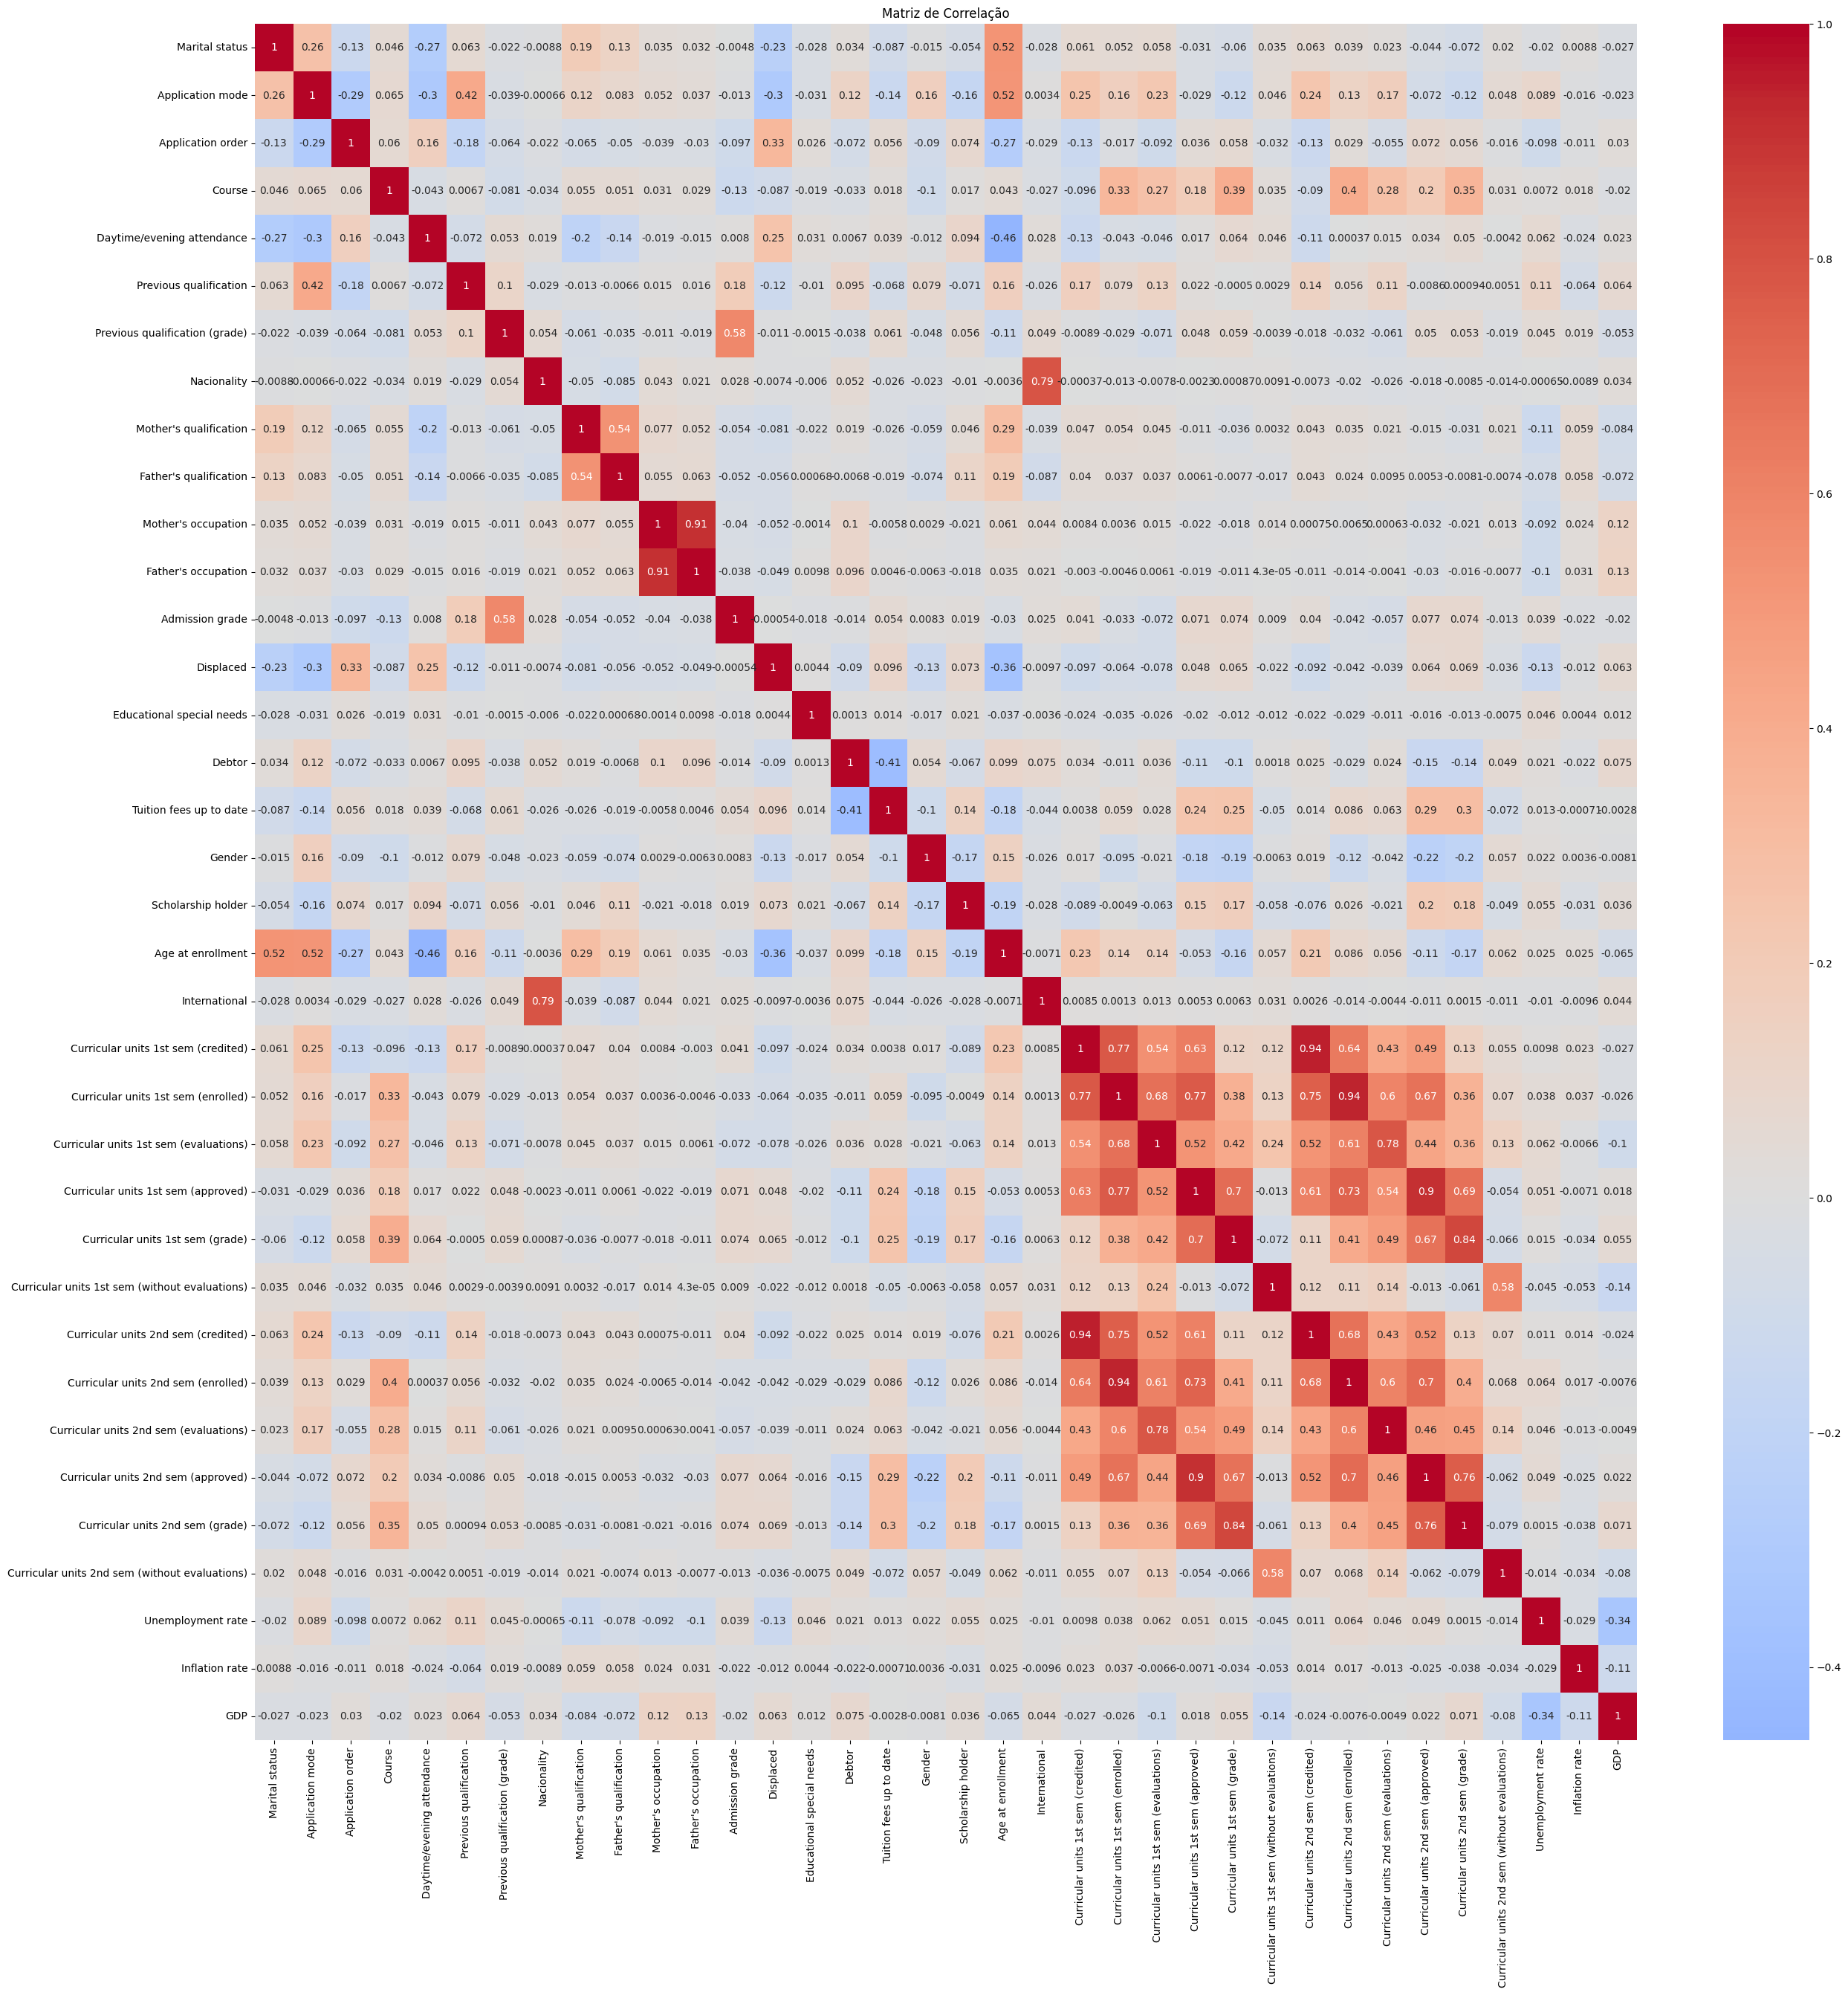

In [5]:

# Matriz de correlação entre os campos dos dados
correlation_matrix = processed_students_df.corr()
plt.figure(figsize = (30, 30))
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', center = 0)
plt.title('Matriz de Correlação')
plt.show()


In [6]:

# Normalização dos dados com min. máx. para usar método PCA
scaler = MinMaxScaler()
scaled_students_df = pd.DataFrame(scaler.fit_transform(processed_students_df), columns = processed_students_df.columns)
scaled_students_df.head(10)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,0.0,0.285714,0.555556,0.013858,1.0,0.000000,0.284211,0.000000,0.418605,0.255814,...,0.0,0.0,0.000000,0.000000,0.00,0.000000,0.000000,0.372093,0.488889,0.766182
1,0.0,0.250000,0.111111,0.925989,1.0,0.000000,0.684211,0.000000,0.000000,0.046512,...,0.0,0.0,0.260870,0.181818,0.30,0.735897,0.000000,0.732558,0.111111,0.640687
2,0.0,0.000000,0.555556,0.907512,1.0,0.000000,0.284211,0.000000,0.837209,0.837209,...,0.0,0.0,0.260870,0.000000,0.00,0.000000,0.000000,0.372093,0.488889,0.766182
3,0.0,0.285714,0.222222,0.978108,1.0,0.000000,0.284211,0.000000,0.860465,0.837209,...,0.0,0.0,0.260870,0.303030,0.25,0.667692,0.000000,0.209302,0.000000,0.124174
4,0.2,0.678571,0.111111,0.801466,0.0,0.000000,0.052632,0.000000,0.837209,0.860465,...,0.0,0.0,0.260870,0.181818,0.30,0.700000,0.000000,0.732558,0.111111,0.640687
5,0.2,0.678571,0.111111,1.000000,0.0,0.428571,0.401053,0.000000,0.837209,0.837209,...,0.0,0.0,0.217391,0.515152,0.25,0.619231,0.416667,1.000000,0.244444,0.414795
6,0.0,0.000000,0.111111,0.950693,1.0,0.000000,0.494737,0.000000,0.418605,0.860465,...,0.0,0.0,0.347826,0.242424,0.40,0.772423,0.000000,0.918605,0.800000,0.000000
7,0.0,0.303571,0.444444,0.925989,1.0,0.000000,0.252632,0.000000,0.837209,0.837209,...,0.0,0.0,0.217391,0.151515,0.00,0.000000,0.000000,0.918605,0.800000,0.000000
8,0.0,0.000000,0.333333,0.924382,1.0,0.000000,0.442105,0.564815,0.000000,0.000000,...,0.0,0.0,0.260870,0.212121,0.30,0.761538,0.000000,1.000000,0.244444,0.414795
9,0.0,0.000000,0.111111,0.924382,1.0,0.000000,0.452632,0.000000,0.000000,0.418605,...,0.0,0.0,0.260870,0.424242,0.10,0.726923,0.000000,0.151163,0.488889,1.000000


In [7]:

pca = PCA(n_components = 2)
pca.fit(scaled_students_df)

print(pca.explained_variance_ratio_)
print(pca.singular_values_)
print(pd.DataFrame(pca.components_, columns = scaled_students_df.columns, index = ['PC1', 'PC2']).T)


[0.16217406 0.12121722]
[39.11206751 33.81444264]
                                                     PC1       PC2
Marital status                                 -0.054934 -0.060297
Application mode                               -0.284526 -0.117931
Application order                               0.087669  0.049969
Course                                          0.022005 -0.106236
Daytime/evening attendance                      0.187801  0.202687
Previous qualification                         -0.100055 -0.024672
Previous qualification (grade)                  0.014279 -0.005766
Nacionality                                     0.000269  0.004669
Mother's qualification                         -0.082431 -0.371208
Father's qualification                         -0.039310 -0.364805
Mother's occupation                            -0.014871 -0.014827
Father's occupation                            -0.011150 -0.013601
Admission grade                                 0.005851  0.003416
Displaced   

<h3>Referências</h3>

<p style="text-align: justify; margin-bottom: 12px;">
CASTRO, Leandro Nunes de; FERRARI, Daniel Gomes. <b>Introdução à mineração de dados: conceitos básicos, algoritmos e aplicações.</b> São Paulo: Saraiva, 2016.
</p>

<p style="text-align: justify; margin-bottom: 12px;">
M.V.Martins, D. Tolledo, J. Machado, L. M.T. Baptista, V.Realinho. (2021) <b>"Early prediction of student’s performance in higher education: a case study" Trends and Applications in Information Systems and Technologies</b>, vol.1, in Advances in Intelligent Systems and Computing series. Springer. DOI: 10.1007/978-3-030-72657-7_16. Acesso em: 8 mar. 2026.
</p>

<p style="text-align: justify; margin-bottom: 12px;">
STATPLACE. <b>Análise de Componentes Principais: o que é, como funciona e exemplos.</b> YouTube. Disponível em: <a href="https://www.youtube.com/watch?v=cOCeXgMKrY8" target="_blank">https://www.youtube.com/watch?v=cOCeXgMKrY8</a>. Acesso em: 15 mar. 2026.
</p>

<p style="text-align: justify; margin-bottom: 12px;">
UCI MACHINE LEARNING REPOSITORY. <b>Predict Students Dropout and Academic Success</b>. Disponível em: <a href="https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success" target="_blank">https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success</a>. Acesso em: 15 mar. 2026.
</p>
